In [1]:
%matplotlib inline

In [2]:
import os
import json
import time
import warnings
warnings.filterwarnings("ignore")

In [3]:
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
from sklearn.decomposition import PCA
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_squared_log_error,
    r2_score,
    make_scorer
)
from sklearn.model_selection import KFold

In [6]:
from xgboost import XGBRegressor
from skopt import BayesSearchCV
from skopt.space import Real, Integer

In [7]:
RANDOM_STATE = 42
USE_GPU = True  # local VS Code CPU
N_COMPONENTS = 20  # fixed, from prior PCA-dimensionality ablation

In [8]:
# ---- 1. Load data ----
DATA_DIR = r"E:\NSU\cse445\EDA attempt3\Dataset\ML dataset"  # <-- update as needed (Kaggle: /kaggle/input/.../kickstarter_joint_embeddings)

In [9]:
TRAIN_FILE = f"{DATA_DIR}/ML_train.csv"
TEST_FILE = f"{DATA_DIR}/ML_test.csv"
BERT_FILE = r"E:\NSU\cse445\EDA attempt3\NLP models\embeddings\bert_embeddings.csv"

In [10]:
train_df = pd.read_csv(TRAIN_FILE)
test_df = pd.read_csv(TEST_FILE)
bert_raw = pd.read_csv(BERT_FILE)

In [11]:
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("BERT shape:", bert_raw.shape)

Train shape: (16000, 81)
Test shape: (4000, 81)
BERT shape: (20000, 769)


In [12]:
TARGET_RAW = "target_usd"
TARGET_LOG = "log_target"
DROP_FROM_X = ["id", "target_usd", "log_target", "goal_usd"]

In [13]:
# ---- 2. PCA reduce BERT embeddings (fit on train only) ----
train_ids = set(train_df["id"])
feature_cols = [c for c in bert_raw.columns if c != "id"]
train_mask = bert_raw["id"].isin(train_ids)

In [14]:
pca = PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
pca.fit(bert_raw.loc[train_mask, feature_cols])
reduced_all = pca.transform(bert_raw[feature_cols])

In [15]:
reduced_cols = [f"bert_pca_{i}" for i in range(N_COMPONENTS)]
reduced_df = pd.DataFrame(reduced_all, columns=reduced_cols)
reduced_df.insert(0, "id", bert_raw["id"].values)

In [16]:
explained = pca.explained_variance_ratio_.sum()
print(f"BERT PCA explained variance: {explained:.3f}")

BERT PCA explained variance: 0.727


In [17]:
# ---- 3. Build the two feature sets ----
merged_train = train_df.merge(reduced_df, on="id", how="left")
merged_test = test_df.merge(reduced_df, on="id", how="left")

In [18]:
assert merged_train.shape[0] == train_df.shape[0]
assert merged_test.shape[0] == test_df.shape[0]
assert merged_train[reduced_cols].isna().sum().sum() == 0
assert merged_test[reduced_cols].isna().sum().sum() == 0

In [19]:
y_train = merged_train[TARGET_LOG].copy()
y_test = merged_test[TARGET_LOG].copy()
actual_usd = merged_test[TARGET_RAW].to_numpy()

In [20]:
# Setup A: BERT-only -> X = just the 20 PCA columns
X_train_bert_only = merged_train[reduced_cols].copy()
X_test_bert_only = merged_test[reduced_cols].copy()

In [21]:
# Setup B: BERT + tabular -> X = PCA columns + all ML_train.csv columns (minus drops)
X_train_full = merged_train.drop(columns=DROP_FROM_X, errors="ignore")
X_test_full = merged_test.drop(columns=DROP_FROM_X, errors="ignore")

In [22]:
assert list(X_train_bert_only.columns) == list(X_test_bert_only.columns)
assert list(X_train_full.columns) == list(X_test_full.columns)

In [23]:
print(f"BERT-only feature count: {X_train_bert_only.shape[1]}")
print(f"BERT+tabular feature count: {X_train_full.shape[1]}")

BERT-only feature count: 20
BERT+tabular feature count: 97


In [24]:
feature_sets = {
    "BERT-only": (X_train_bert_only, X_test_bert_only),
    "BERT+Tabular": (X_train_full, X_test_full),
}

In [25]:
# ---- 4. Evaluation helper ----
def evaluate_model(y_true_log, pred_log, actual_usd):
    pred_usd = np.expm1(pred_log)
    pred_usd = np.clip(pred_usd, a_min=0, a_max=None)

    mae_log = mean_absolute_error(y_true_log, pred_log)
    mse_log = mean_squared_error(y_true_log, pred_log)
    rmse_log = np.sqrt(mse_log)
    r2_log = r2_score(y_true_log, pred_log)

    mae_usd = mean_absolute_error(actual_usd, pred_usd)
    mse_usd = mean_squared_error(actual_usd, pred_usd)
    rmse_usd = np.sqrt(mse_usd)
    r2_usd = r2_score(actual_usd, pred_usd)

    rmsle = np.sqrt(mean_squared_log_error(actual_usd, pred_usd))

    return {
        "MAE_log": mae_log, "MSE_log": mse_log, "RMSE_log": rmse_log, "R2_log": r2_log,
        "MAE_USD": mae_usd, "MSE_USD": mse_usd, "RMSE_USD": rmse_usd, "R2_USD": r2_usd,
        "RMSLE": rmsle
    }

In [26]:
# ---- 5. BayesSearchCV setup (fixed across both feature sets) ----
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

In [27]:
rmse_scorer = make_scorer(rmse, greater_is_better=False)
CV = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
N_ITER_BAYES = 4

In [28]:
xgb_bayes_space = {
    "n_estimators":     Integer(200, 500),
    "learning_rate":    Real(0.01, 0.1, prior="log-uniform"),
    "max_depth":        Integer(4, 9),
    "min_child_weight": Integer(1, 7),
    "subsample":        Real(0.7, 1.0),
    "colsample_bytree": Real(0.7, 1.0),
    "reg_alpha":        Real(1e-3, 0.5, prior="log-uniform"),
    "reg_lambda":       Real(0.5, 3.0),
}

In [29]:
def make_search():
    base_estimator = XGBRegressor(
        objective="reg:squarederror", eval_metric="rmse",
        tree_method="hist", device="cuda" if USE_GPU else "cpu",
        random_state=RANDOM_STATE,
    )
    return BayesSearchCV(
        estimator=base_estimator, search_spaces=xgb_bayes_space, n_iter=N_ITER_BAYES,
        scoring=rmse_scorer, cv=CV, n_jobs=1,
        random_state=RANDOM_STATE, verbose=0, refit=True,
    )

In [30]:
# ---- 6. Ablation loop over feature sets ----
ablation_results = []
best_params_by_setup = {}

In [31]:
for setup_name, (X_train, X_test) in feature_sets.items():
    print(f"\n{'='*70}")
    print(f"FEATURE SET = {setup_name}  ({X_train.shape[1]} features)")
    print(f"{'='*70}")

    search = make_search()
    start_time = time.time()
    search.fit(X_train, y_train)
    tuning_time = time.time() - start_time

    best_model = search.best_estimator_
    pred_log = best_model.predict(X_test)

    metrics = evaluate_model(y_test, pred_log, actual_usd)
    metrics["Feature_Set"] = setup_name
    metrics["N_Features"] = X_train.shape[1]
    metrics["Best_CV_RMSE_log"] = -search.best_score_
    metrics["Tuning_Time_Seconds"] = tuning_time

    ablation_results.append(metrics)
    best_params_by_setup[setup_name] = dict(search.best_params_)

    print(f"RMSLE={metrics['RMSLE']:.4f} | R2_log={metrics['R2_log']:.4f} | "
          f"R2_USD={metrics['R2_USD']:.4f} | time={tuning_time:.1f}s")


FEATURE SET = BERT-only  (20 features)
RMSLE=1.7990 | R2_log=0.6544 | R2_USD=0.1262 | time=58.3s

FEATURE SET = BERT+Tabular  (97 features)
RMSLE=1.5065 | R2_log=0.7578 | R2_USD=0.1769 | time=67.3s


In [32]:
# ---- 7. Results table ----
results_df = pd.DataFrame(ablation_results)
results_df = results_df[[
    "Feature_Set", "N_Features",
    "MAE_log", "MSE_log", "RMSE_log", "R2_log",
    "MAE_USD", "MSE_USD", "RMSE_USD", "R2_USD",
    "RMSLE", "Best_CV_RMSE_log", "Tuning_Time_Seconds"
]]
print("\n" + "="*70)
print("ABLATION RESULTS: BERT-only vs BERT+Tabular")
print("="*70)
print(results_df)


ABLATION RESULTS: BERT-only vs BERT+Tabular
    Feature_Set  N_Features   MAE_log   MSE_log  RMSE_log    R2_log  \
0     BERT-only          20  1.362447  3.246647  1.801846  0.654419   
1  BERT+Tabular          97  1.115845  2.275488  1.508472  0.757791   

        MAE_USD       MSE_USD       RMSE_USD    R2_USD     RMSLE  \
0  15802.597575  1.031190e+10  101547.511232  0.126221  1.799043   
1  14587.044370  9.713670e+09   98557.950385  0.176912  1.506474   

   Best_CV_RMSE_log  Tuning_Time_Seconds  
0          1.799861            58.338808  
1          1.535839            67.339695  


In [33]:
results_df.to_csv("bert_featureset_ablation_results.csv", index=False)
with open("bert_featureset_ablation_best_params.json", "w") as f:
    json.dump(best_params_by_setup, f, indent=2, default=str)

In [34]:
print("\nSaved: bert_featureset_ablation_results.csv")
print("Saved: bert_featureset_ablation_best_params.json")


Saved: bert_featureset_ablation_results.csv
Saved: bert_featureset_ablation_best_params.json


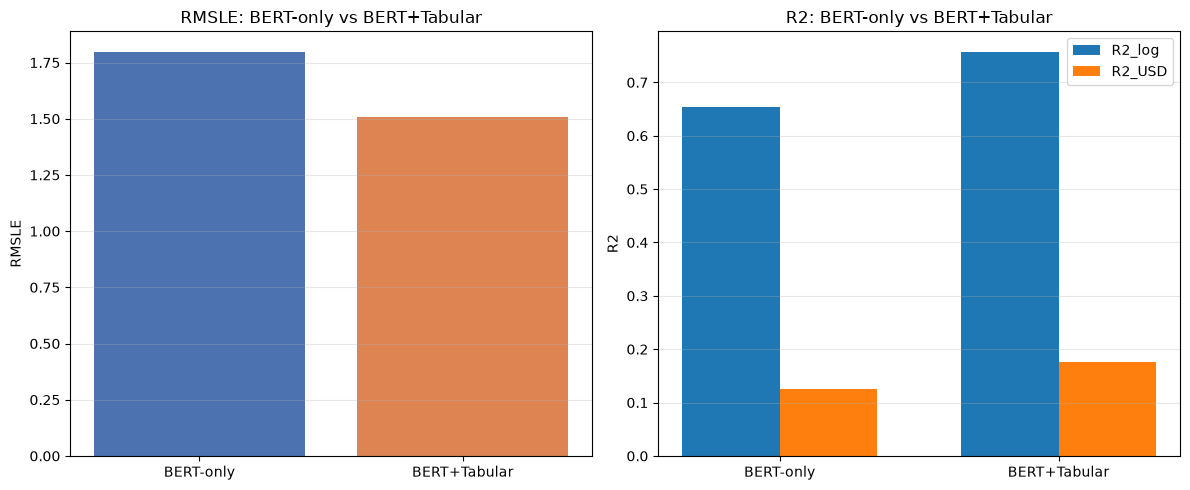

Saved: bert_featureset_ablation_plot.png


In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(results_df["Feature_Set"], results_df["RMSLE"], color=["#4C72B0", "#DD8452"])
axes[0].set_ylabel("RMSLE")
axes[0].set_title("RMSLE: BERT-only vs BERT+Tabular")
axes[0].grid(True, alpha=0.3, axis="y")

x = np.arange(len(results_df))
width = 0.35
axes[1].bar(x - width/2, results_df["R2_log"], width, label="R2_log")
axes[1].bar(x + width/2, results_df["R2_USD"], width, label="R2_USD")
axes[1].set_xticks(x)
axes[1].set_xticklabels(results_df["Feature_Set"])
axes[1].set_ylabel("R2")
axes[1].set_title("R2: BERT-only vs BERT+Tabular")
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("bert_featureset_ablation_plot.png", dpi=150)
plt.show()
print("Saved: bert_featureset_ablation_plot.png")